# Spotify Track Genre Classification
## Classificazione multiclass del genere musicale

**Programmazione di Applicazioni Data Intensive**  
Laurea in Ingegneria e Scienze Informatiche  
DISI - Università di Bologna, Cesena

Si deve realizzare un modello di classificazione che, utilizzando le feature audio estratte dall'API Spotify (energia, danceability, valence, acousticness, ecc.), sia in grado di predire il genere musicale di una traccia.

Il dataset Spotify contiene 114,000 tracce distribuite su 114 generi diversi, con feature numeriche che caratterizzano proprietà fisiche e percettive della musica.

Il dataset usato nel notebook è maharshipandya/spotify-tracks-dataset, scaricato da HuggingFace e basato su feature audio rese disponibili da Spotify. Vengono importate le librerie necessarie per scaricare il dataset, organizzare le strutture dati e creare visualizzazioni.

### Importazione librerie

In [35]:
%pip install datasets scikit-learn seaborn -q

Note: you may need to restart the kernel to use updated packages.


In [36]:
from datasets import load_dataset
%matplotlib inline
import os.path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split

### Caricamento dei dati

In [37]:
file = 'spotify_tracks.csv'
if not os.path.exists('spotify_tracks.csv'):
    print('Downloading Spotify dataset...')
    dataset = load_dataset('maharshipandya/spotify-tracks-dataset')
    df_genre = pd.DataFrame(dataset['train'])
    print(f'Dataset scaricato!')
    print(f'Shape: {df_genre.shape}')
    df_genre.to_csv(file, index=False)
    print(f'\nDataset salvato in: {file}')
else:
    print('Dataset già presente. Caricamento da file...')
    df_genre = pd.read_csv(file)
    print(f'Dataset caricato da: {file}')
    print(f'Shape: {df_genre.shape}')

Dataset già presente. Caricamento da file...
Dataset caricato da: spotify_tracks.csv
Shape: (114000, 21)


Visualizzo ora le prime righe del dataset:

In [38]:
df_genre.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### Descrizione delle feature

Il dataset Spotify contiene le seguenti colonne:

**Metadati:**
- `track_id`: ID univoco della traccia su Spotify
- `artists`: Nomi degli artisti (se più artisti, separati da ';')
- `album_name`: Nome dell'album
- `track_name`: Nome della traccia

**Feature Audio :**
- `popularity`: Popolarità (0-100) calcolata da Spotify; valori più alti indicano brani più ascoltati recentemente
- `duration_ms`: Durata della traccia in millisecondi
- `explicit`: Contenuto esplicito? (true = sì; false = no o sconosciuto)
- `danceability`: Indice (0.0-1.0) che misura quanto la traccia è adatta al ballo
- `energy`: Indice (0.0-1.0) di intensità/energia percepita
- `key`: Tonalità (0=C, 1=C♯/D♭, 2=D, ...). -1 se non rilevata
- `loudness`: Loudness complessiva in decibel (dB)
- `mode`: Modalità (1 = maggiore, 0 = minore)
- `speechiness`: Presenza di parlato (valori >0.66 indicano probabile parlato puro; 0.33-0.66 indicano mix)
- `acousticness`: Confidenza che la traccia sia acustica (0.0-1.0)
- `instrumentalness`: Probabilità che la traccia sia strumentale (più alto = più probabile assenza di vocali)
- `liveness`: Probabilità che la traccia sia registrata dal vivo (valori >0.8 indicano performance live)
- `valence`: Indice (0.0-1.0) di positività emotiva della traccia (alto = più allegra)
- `tempo`: Tempo stimato in battiti per minuto (BPM)
- `time_signature`: Firma ritmica stimata (3-7, es. 4 => 4/4)
- `track_genre`: Genere della traccia

Separo id, nome album e artista perché non portano informazioni utili al riconoscimento del genere: il modello deve riconsocere il genere a prescidere dall'album e da chi suona

In [39]:
feature_cols = ['popularity', 'duration_ms', 'danceability', 'energy', 'explicit',
                'key', 'loudness', 'mode', 'speechiness', 'acousticness',
                'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
genre_col = 'track_genre'

metadata_cols = ['track_id', 'track_name', 'artists', 'album_name']

metadata = df_genre[metadata_cols].copy()
df_genre = df_genre[feature_cols + [genre_col]].copy()

Controllo le righe che contengono valori null:

In [40]:
df_genre.isnull().sum()

popularity          0
duration_ms         0
danceability        0
energy              0
explicit            0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Non ci sono rows che hanno valori null, per cui non faccio nulla

###  Analisi Esplorativa




Con il metodo describe() è possibile avere una rappresentazione statistica delle feature numeriche, ottenendo media, deviazione standard e la distribuzione in termini di massimi, minimi e percentili.

In [41]:
df_genre.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


L'**energia** e la **danceability** mostrano una distribuzione ampia e variegata, suggerendo che questi attributi sono fortemente caratterizzanti per la discriminazione tra generi diversi; brani energici e danzabili tendono a concentrarsi in generi specifici (pop, dance, electronic), mentre brani meno energici caratterizzano generi come lo slowcore o il folk. 

La **valence** (positività emotiva) presenta una distribuzione diffusa su tutto lo spettro (0.0-1.0), il che indica che questo parametro è un discriminante importante nel classificare generi melanconici versus generi più positivi e vivaci. Il **tempo** (BPM) varia considerevolmente tra le tracce, evidenziando come generi diversi abbiano velocità caratteristiche: generi veloci come l'EDM e il punk contrastano con generi lenti.

La **popolarità** si concentra su valori medio-bassi, indicando che il modello avrà accesso a una varietà di generi sia mainstream che di nicchia.

Feature come **acousticness** e **instrumentalness** mostrano distribuzioni asimmetriche con valori generalmente bassi, riflettendo il predominio di musica prodotta elettronicamente e vocale nel dataset, tuttavia i picchi in queste feature permetteranno di identificare generi più acustici.

L'**intelligibilità del parlato** (speechiness) rimane bassa nella maggior parte delle tracce, ma la presenza di outlier potrebbe aiutare a identificare generi come il rap.

### Analisi del target: track_genre

In [42]:
generi_completi = sorted(df_genre['track_genre'].unique())
print(f"Ci sono {len(generi_completi)} generi totali:\n")
for g in generi_completi:
    print(g)


Ci sono 114 generi totali:

acoustic
afrobeat
alt-rock
alternative
ambient
anime
black-metal
bluegrass
blues
brazil
breakbeat
british
cantopop
chicago-house
children
chill
classical
club
comedy
country
dance
dancehall
death-metal
deep-house
detroit-techno
disco
disney
drum-and-bass
dub
dubstep
edm
electro
electronic
emo
folk
forro
french
funk
garage
german
gospel
goth
grindcore
groove
grunge
guitar
happy
hard-rock
hardcore
hardstyle
heavy-metal
hip-hop
honky-tonk
house
idm
indian
indie
indie-pop
industrial
iranian
j-dance
j-idol
j-pop
j-rock
jazz
k-pop
kids
latin
latino
malay
mandopop
metal
metalcore
minimal-techno
mpb
new-age
opera
pagode
party
piano
pop
pop-film
power-pop
progressive-house
psych-rock
punk
punk-rock
r-n-b
reggae
reggaeton
rock
rock-n-roll
rockabilly
romance
sad
salsa
samba
sertanejo
show-tunes
singer-songwriter
ska
sleep
songwriter
soul
spanish
study
swedish
synth-pop
tango
techno
trance
trip-hop
turkish
world-music


I 114 generi vengono raggruppati in 8 macrogeneri sulla base delle caratteristiche audio. Vengono esclusi i generi definiti solamente dalla lingua o dalla provenienza geografica (es. french, latin, swedish), dal contesto d'uso (es. sleep, study, children) o dall'umore (es. happy, sad) — categorie che le feature acustiche di Spotify non sono in grado di distinguere in modo affidabile, e che introdurrebbero solo rumore nel modello.

In [ ]:
macrogeneri_clean = {
    "Rock, Punk & Hardcore": [
        "alt-rock", "alternative", "grunge", "hard-rock", "indie", "psych-rock",
        "rock", "rock-n-roll", "rockabilly", "j-rock", "emo", "goth", "hardcore", "punk", "punk-rock", "ska"
    ],
    "Metal": [
        "black-metal", "death-metal", "grindcore", "heavy-metal", "industrial", "metal", "metalcore"
    ],
    "Pop": [
        "pop", "indie-pop", "power-pop", "synth-pop",
        "cantopop", "j-pop", "k-pop", "mandopop", "j-idol"
    ],
    "Electronic, Dance & Club": [
        "club", "dance", "disco", "house", "chicago-house", "deep-house", "progressive-house",
        "hardstyle", "garage", "j-dance", "electronic", "breakbeat", "detroit-techno",
        "drum-and-bass", "dub", "dubstep", "edm", "electro", "idm", "minimal-techno",
        "techno", "trance", "trip-hop", "ambient", "chill", "reggaeton"
    ],
    "Hip-Hop, R&B & Soul": [
        "hip-hop", "r-n-b", "soul", "funk", "gospel", "groove", "reggae", "dancehall", "afrobeat"
    ],
    "Jazz & Blues": [
        "jazz", "blues"
    ],
    "Folk & Country": [
        "acoustic", "bluegrass", "country", "folk", "forro", "honky-tonk",
        "singer-songwriter", "songwriter", "guitar"
    ],
    "Classical": [
        "classical", "opera", "piano", "new-age"
    ]
}

# Costruisce il dizionario inverso: da sotto-genere a macrogenere
genere_to_macro = {sotto_genere: macro for macro, sotto_generi in macrogeneri_clean.items() for sotto_genere in sotto_generi}

df = df_genre.copy()
# Sostituisce la colonna track_genre con il corrispondente macrogenere
df['genre'] = df['track_genre'].map(genere_to_macro)

# Rimuove le tracce il cui sotto-genere non appartiene ad alcun macrogenere definito
df = df.drop(columns="track_genre")
df = df.dropna(subset=['genre'])

print(f"Righe dopo la pulizia: {len(df)}")

Righe dopo la pulizia: 78000


Trasformo la feature explicit (bool) in 0 e 1

In [29]:
df['explicit'] = df['explicit'].astype(int)

### Analisi della distribuzione dei generi

Il dataset originario aveva esattamente 1000 tracce per genere. Controlliamo invece dopo la suddivisione in macrogenere:

In [30]:
genres = df['genre'].value_counts()
print(f'\nNumero di tracce per macrogenere:')
print(genres.head(20))
print(f"Rows: {len(df)}")


Numero di tracce per macrogenere:
genre
Electronic, Dance & Club    25000
Rock, Punk & Hardcore       16000
Pop                         13000
Folk & Country               9000
Metal                        7000
Hip-Hop, R&B & Soul          6000
Classical                    4000
Jazz & Blues                 2000
Name: count, dtype: int64
Rows: 82000


<Axes: >

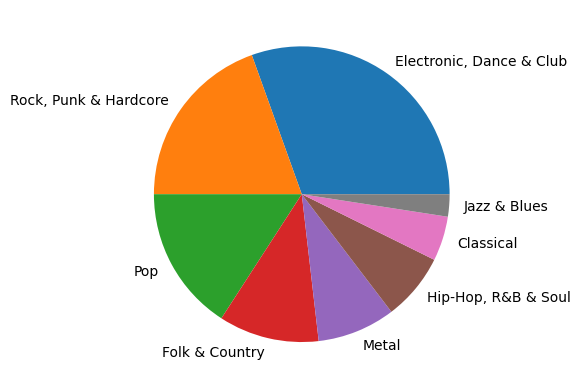

In [31]:
df["genre"].value_counts().plot(kind="pie")

In questo caso la distribuzione è sbilanciata e si dovrà agire per contrastare il problema

### Distribuzioni individuali delle feature

Passiamo ora ad analizzare la distibuzione delle feature:

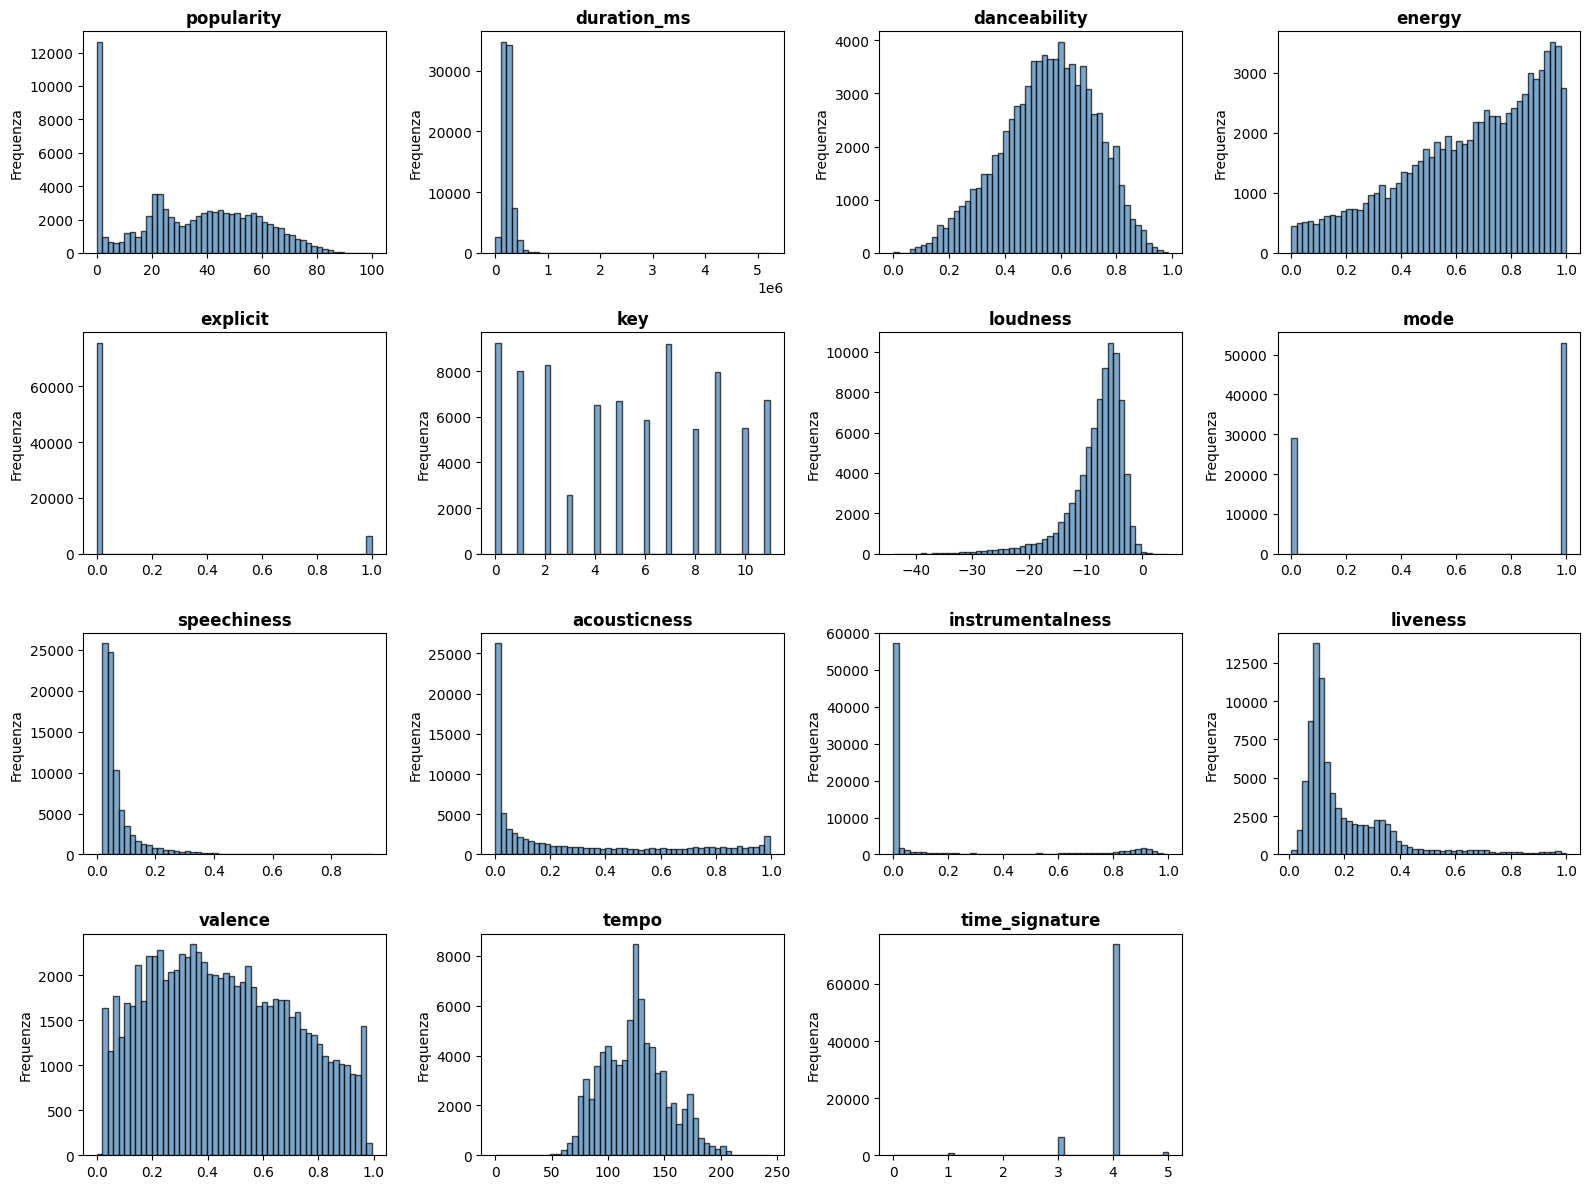

In [32]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(feature_cols):
    axes[idx].hist(df[col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(col, fontweight='bold')
    axes[idx].set_ylabel('Frequenza')
# Nasconde i pannelli vuoti se le feature sono meno dei subplot disponibili
for i in range(len(feature_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

Gli istogrammi mostrano le distribuzioni individuali di ogni feature.
-  **Energy** e **danceability** presentano distribuzioni relativamente uniformi con leggera concentrazione verso valori medio-alti, indicando varietà nei brani del dataset. 
- **Acousticness** e **instrumentalness** mostrano distribuzioni fortemente asimmetriche verso valori bassi, coerente con il predominio di musica elettronica e vocale nel dataset moderno. 
- **Valence** ha una distribuzione simile a quella di energy, ampia e diffusa. 
- **Speechiness** è concentrata verso valori molto bassi, riflettendo il fatto che la maggior parte della musica contiene poco parlato. 
- **Loudness** mostra una distribuzione approssimativamente normale centrata intorno a -5/-6 dB.
-  **Duration** ha una distribuzione con coda lunga, con la maggior parte delle tracce intorno ai 3-4 minuti ma con alcuni outliers molto lunghi.

Ci sono delle feature che si possono togliere:

- **liveness**: Questa variabile indica la probabilità che la traccia sia registrata dal vivo. Dai grafici si vede che la stragrande maggioranza dei brani nel dataset presenta un valore prossimo allo zero (registrazioni in studio). Essendo una feature fortemente sbilanciata e non direttamente correlata alle caratteristiche timbriche o strutturali di un genere musicale, la sua inclusione rischierebbe di introdurre solo rumore (noise) nel modello, senza contribuire alla discriminazione tra le classi.
- **popularity**: Sebbene sia una metrica interessante per analisi di mercato, la popolarità è una variabile estrinseca al contenuto sonoro della traccia. Un brano può essere molto popolare o di nicchia all'interno di qualsiasi genere musicale; pertanto, includerla comporterebbe il rischio di "data leakage" (il modello potrebbe imparare a classificare i generi in base alla loro diffusione commerciale anziché alle loro proprietà acustiche), non aiutando a generalizzare le caratteristiche sonore del genere stesso.

In [33]:
df.drop(columns=['liveness', 'popularity'], inplace=True)

### Feature Engineering

La variabile `key` indica la tonalità della traccia con un valore intero da 0 (Do) a 11 (Si). Trattarla come numero continuo implica un ordine lineare inesistente: per un modello lineare come la Logistic Regression, sostenere che Si (11) è "undici volte" Do (0) non ha senso musicale.

Per correggere questo, applichiamo **one-hot encoding**: ogni tonalità diventa una colonna binaria indipendente.

In [34]:
df = pd.get_dummies(df, columns=['key'], prefix='key', drop_first=True)

print(f'Colonne dopo one-hot encoding di key: {df.shape[1]}')
print([c for c in df.columns if c.startswith('key_')])

Colonne dopo one-hot encoding di key: 24
['key_1', 'key_2', 'key_3', 'key_4', 'key_5', 'key_6', 'key_7', 'key_8', 'key_9', 'key_10', 'key_11']


La colonna `key` è stata sostituita da 11 variabili binarie (`key_1` … `key_11`). La tonalità 0 (Do) funge da categoria di riferimento implicita (drop_first=True).

Aggiorniamo anche `feature_cols` per riflettere le nuove colonne prima di separare X e y.

In [ ]:
feature_cols = [c for c in df.columns if c != 'genre']
print(f'Feature totali dopo encoding: {len(feature_cols)}')

Feature totali dopo encoding: 23


### Boxplot per feature principali per genere

Text(0.5, 0.98, '')

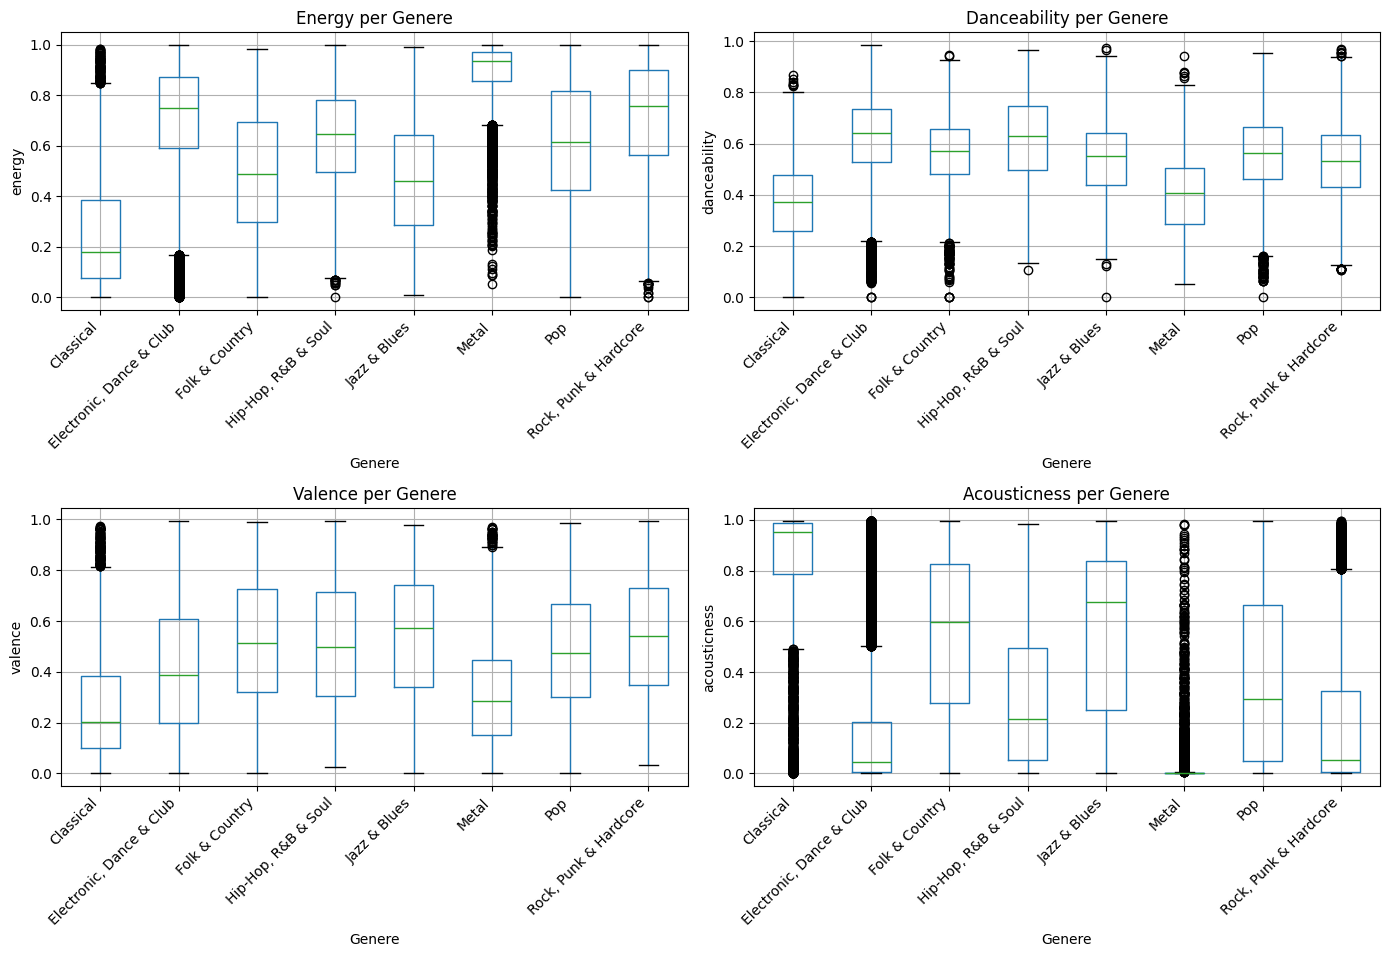

In [174]:
main_features = ['energy', 'danceability', 'valence', 'acousticness']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = np.array(axes, dtype=object)
if axes.ndim == 1 and axes.size == 4:
    axes = axes.reshape(2,2)
for idx, feature in enumerate(main_features):
    ax = axes[idx // 2, idx % 2]
    try:
        df.boxplot(column=feature, by='genre', ax=ax)
        ax.set_xlabel('Genere')
        ax.set_ylabel(feature)
        ax.set_title(f'{feature.capitalize()} per Genere')
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    except Exception as e:
        ax.text(0.5, 0.5, f'Errore plotting {feature}: {e}', ha='center')
plt.tight_layout()
plt.suptitle('')



I boxplot mostrano differenze significative nelle feature principali tra i generi. 
- Per la feature **energy**, si osserva che i generi rock e metal, hanno mediamente valori più alti, mentre generi come classical hanno valori bassi. 
- Per **danceability**, il pattern è simile: generi tipicamente danzabili (dance, house, pop) hanno mediane più alte rispetto a generi come classical o metal.
-  La feature **valence** mostra variabilità tra generi, con alcuni come happy o pop che tendono verso valori più alti. Per **acousticness**, il contrasto è molto evidente: generi come acoustic e folk hanno valori molto alti, mentre dance ed electronic hanno valori quasi nulli.

I boxplot evidenziano le differenze chiave tra i macro-generi:
- **Outlier**: La presenza massiccia di punti neri (es. in Electronic, Metal) è naturale: indica che, sebbene la maggior parte dei brani abbia caratteristiche omogenee (es. bassa acousticness), esistono eccezioni (brani acustici isolati) che vengono segnalate come anomalie statistiche.
- **Coerenza**:
Classical si conferma all'opposto di Dance/Electronic per Acousticness ed Energy.
Folk mostra la variabilità interna più alta (box più lunghi).
Punk/Hardcore e Rock mantengono profili energetici coerenti e distinti dal pop commerciale.

### Matrice di correlazione tra feature

Passiamo ora a visualizzare la correlazione tra le feature:

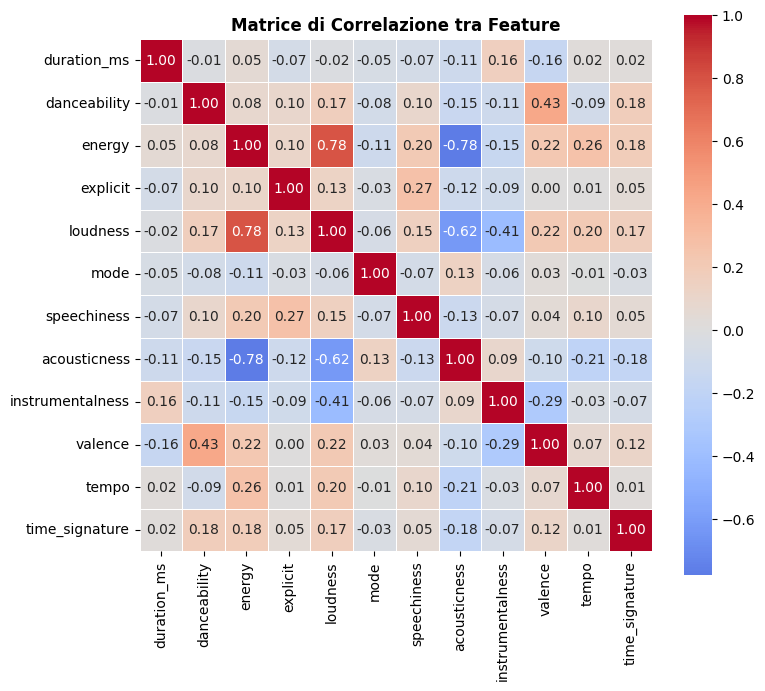

In [175]:
corr_matrix = df.select_dtypes(include=[np.number]).corr()

fig, ax = plt.subplots(figsize=(8, 8))
sb.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
           square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Matrice di Correlazione tra Feature', fontweight='bold')
plt.tight_layout()
plt.show()

La matrice di correlazione rivela le relazioni lineari tra le feature. Le correlazioni più notevoli sono:
- **Energy e Loudness** (~0.70): correlazione positiva forte, naturale poiché brani energici tendono ad essere più forti
- **Acousticness e Energy** (~-0.60): correlazione negativa, coerente con il fatto che brani acustici sono tipicamente meno intensi
- **Valence e Energy** (~0.50): correlazione positiva moderata, suggerendo che brani energici tendono ad essere più positivi

Queste correlazioni moderate indicano che le feature catturano aspetti diversi della musica, il che è favorevole per il modello: una correlazione troppo alta comporterebbe ridondanza di informazione, mentre una correlazione troppo bassa suggerirebbe che le feature catturano fenomeni indipendenti.

### Correlazione di ogni feature con il genere

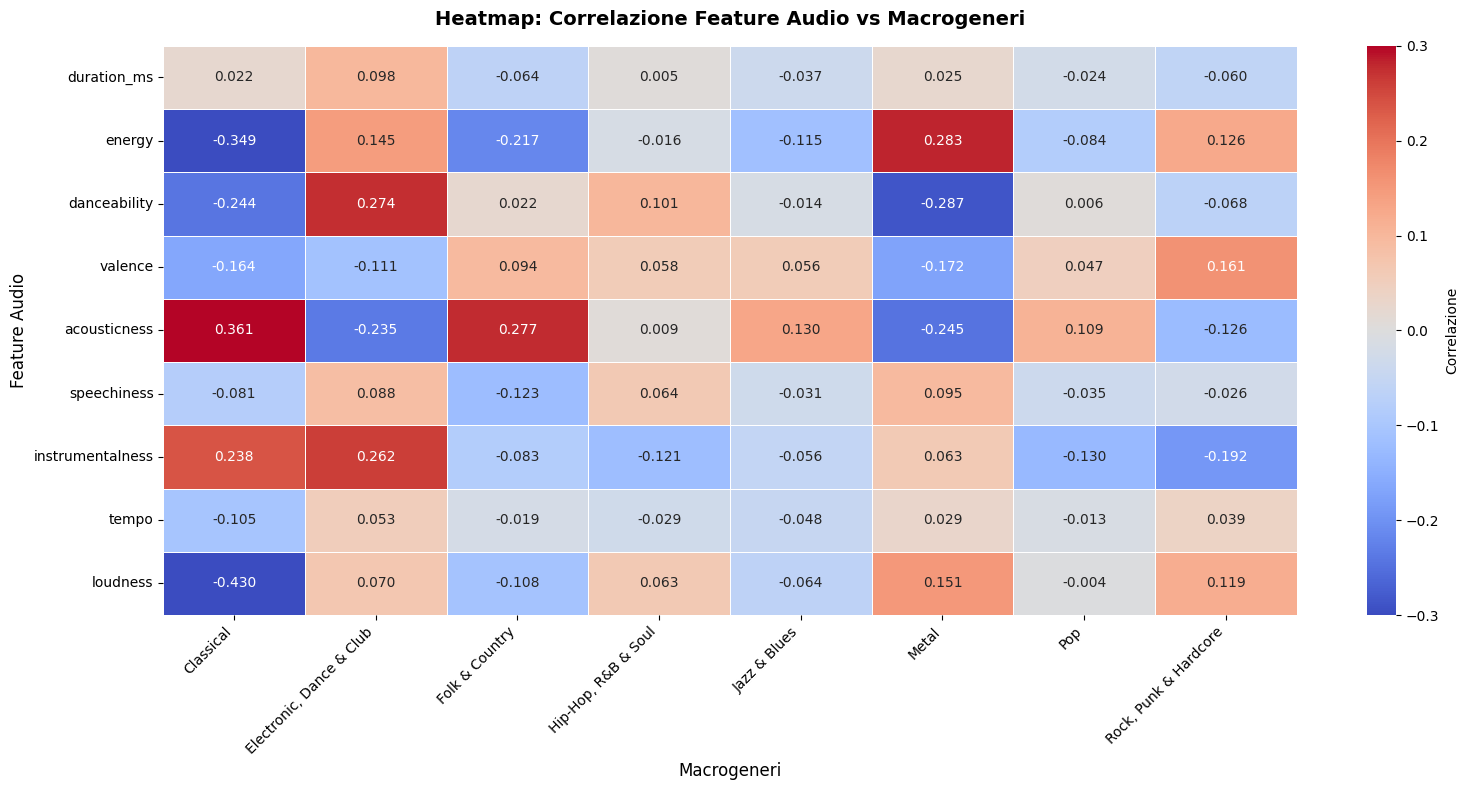

Heatmap delle correlazioni creata.


In [176]:
audio_features = ['duration_ms', 'energy', 'danceability', 'valence', 'acousticness', 
                    'speechiness', 'instrumentalness', 'tempo', 'loudness']
audio_features = [f for f in audio_features if f in df.columns]

macro_dummies = pd.get_dummies(df['genre'], prefix='genre', drop_first=False)

matrix_corr_data = {}
for feature in audio_features:
    correlations = {}
    for col in macro_dummies.columns:
        corr = df[feature].corr(macro_dummies[col])
        genre_name = col.replace('genre_', '')
        correlations[genre_name] = corr
    matrix_corr_data[feature] = correlations

matrix_corr = pd.DataFrame(matrix_corr_data).T

plt.figure(figsize=(16, 8))
sb.heatmap(
    matrix_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.3f',
    linewidths=0.5,
    cbar_kws={'label': 'Correlazione'},
    vmin=-0.3, vmax=0.3
)
plt.title('Heatmap: Correlazione Feature Audio vs Macrogeneri', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Macrogeneri', fontsize=12)
plt.ylabel('Feature Audio', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Heatmap delle correlazioni creata.")



Tutte le correlazioni individuali tra le feature e il genere sono basse. Ciò significa che **nessuna singola feature è in grado di predire il genere in modo univoco**. il genere musicale non è determinato da una sola caratteristica fisica, ma dall'interazione di molteplici attributi.

Tuttavia, questo non è un problema per il nostro modello. I modelli di machine learning come Random Forest sono specificamente progettati per scoprire **combinazioni non-lineari** di feature che insieme hanno grande potere predittivo. Il fatto che le feature individuali abbiano bassa correlazione suggerisce che il modello avrà bisogno di catturare interazioni complesse tra le feature, il che rende il problema interessante dal punto di vista del learning.

Rimuoviamo eventuali rows con valori nulli:

In [177]:
df.isna().sum()

duration_ms         0
danceability        0
energy              0
explicit            0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
valence             0
tempo               0
time_signature      0
genre               0
key_1               0
key_2               0
key_3               0
key_4               0
key_5               0
key_6               0
key_7               0
key_8               0
key_9               0
key_10              0
key_11              0
dtype: int64

Prepariamo i dati per l'addestramento: separiamo variabili predittive e feature target.

In [178]:
y = df['genre']
X = df.drop(columns=['genre'])

Dividiamo ora in training e test set

In [179]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       
    random_state=42,    
    stratify=y #per mantenere proporzioni di classi
)


Le classi restano sbilanciate dopo il raggruppamento in macrogeneri, quindi uso `class_weight='balanced'` nei modelli che lo supportano. In questo modo evito oversampling artificiale e mantengo il confronto piu` semplice e leggibile.


### Modello baseline casuale


Questo modello assegna le classi a caso ed è solo un riferimento minimo: un modello utile deve superarlo in modo netto.


In [180]:
from sklearn.dummy import DummyClassifier

random_baseline = DummyClassifier(strategy='stratified', random_state=42)
random_baseline.fit(X_train, y_train)


,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'stratified'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


Il baseline stratificato serve come riferimento minimo: predice le classi 
rispettando le proporzioni reali del training set, senza usare nessuna feature. 
Un modello utile deve superarlo in modo netto.


### Modello 1: Logistic Regression (con Pipeline)

In [181]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logisticRegression = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, class_weight='balanced'))
])
logisticRegression.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may n

### Modello 2: RandomForest (con Pipeline)

In [182]:
from sklearn.ensemble import RandomForestClassifier

randomForest = Pipeline([
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced'))
])

randomForest.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.

### Modello 3: LightGBM (con Pipeline)

In [183]:
from lightgbm import LGBMClassifier

lgb = Pipeline([
    ('classifier', LGBMClassifier(n_estimators=100, verbose=-1, random_state=42, class_weight='balanced'))
])
lgb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None


### Confronto dei Modelli

Definiamo una funzione che stampi le metriche di valutazione:

In [184]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, top_k_accuracy_score
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, bool_show_confusion=False):
    # Predizioni sull'insieme di test
    y_pred = model.predict(X_test)
    
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # Metriche aggregate pesate per numero di istanze per classe
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Top-2 accuracy: conta come corretta anche la predizione se il genere reale
    # rientra tra i due più probabili.
    probs = model.predict_proba(X_test)
    top2 = top_k_accuracy_score(y_test, probs, k=2, labels=model.classes_)
    print(f"Top-2 Accuracy: {top2:.4f}")
    if not bool_show_confusion:
        return
    
    # Matrice di confusione: mostra dove il modello confonde i generi tra loro
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap='Blues', xticks_rotation=90)
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

Classification Report:
                          precision    recall  f1-score   support

               Classical       0.04      0.04      0.04       800
Electronic, Dance & Club       0.31      0.31      0.31      5000
          Folk & Country       0.11      0.11      0.11      1800
     Hip-Hop, R&B & Soul       0.08      0.08      0.08      1200
            Jazz & Blues       0.03      0.03      0.03       400
                   Metal       0.08      0.08      0.08      1400
                     Pop       0.16      0.16      0.16      2600
   Rock, Punk & Hardcore       0.20      0.20      0.20      3200

                accuracy                           0.19     16400
               macro avg       0.13      0.13      0.13     16400
            weighted avg       0.19      0.19      0.19     16400

Accuracy: 0.1863
Precision: 0.1860
Recall: 0.1863
F1 Score: 0.1861
Top-2 Accuracy: 0.3742


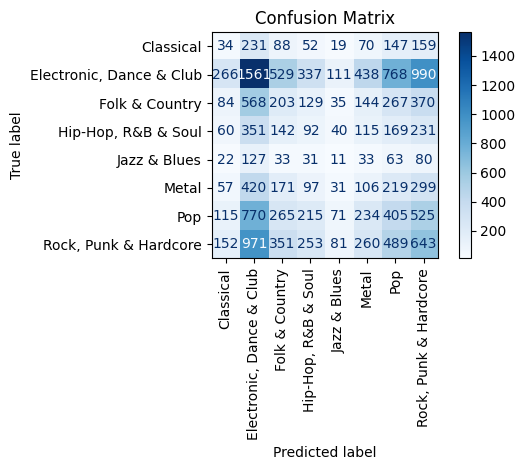

In [185]:
evaluate_model(random_baseline, X_test, y_test, True)

Classification Report:
                          precision    recall  f1-score   support

               Classical       0.43      0.70      0.53       800
Electronic, Dance & Club       0.75      0.47      0.58      5000
          Folk & Country       0.35      0.39      0.37      1800
     Hip-Hop, R&B & Soul       0.17      0.32      0.22      1200
            Jazz & Blues       0.11      0.43      0.18       400
                   Metal       0.42      0.78      0.55      1400
                     Pop       0.24      0.06      0.09      2600
   Rock, Punk & Hardcore       0.37      0.34      0.35      3200

                accuracy                           0.40     16400
               macro avg       0.35      0.44      0.36     16400
            weighted avg       0.45      0.40      0.39     16400

Accuracy: 0.3969
Precision: 0.4486
Recall: 0.3969
F1 Score: 0.3940
Top-2 Accuracy: 0.5916


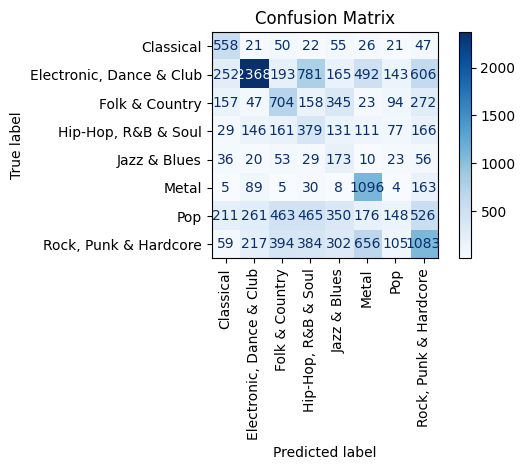

In [186]:
evaluate_model(logisticRegression, X_test, y_test, True)

La logistic regression supera il caso, ma resta il modello più debole tra quelli provati: la frontiera lineare cattura solo una parte della struttura del problema. Il fatto che il top-2 sia molto più alto dell'accuracy dice che spesso il genere corretto è comunque tra le prime alternative suggerite.


Classification Report:
                          precision    recall  f1-score   support

               Classical       0.63      0.64      0.64       800
Electronic, Dance & Club       0.70      0.79      0.74      5000
          Folk & Country       0.61      0.63      0.62      1800
     Hip-Hop, R&B & Soul       0.52      0.33      0.41      1200
            Jazz & Blues       0.44      0.42      0.43       400
                   Metal       0.65      0.64      0.64      1400
                     Pop       0.50      0.47      0.49      2600
   Rock, Punk & Hardcore       0.53      0.52      0.52      3200

                accuracy                           0.61     16400
               macro avg       0.57      0.56      0.56     16400
            weighted avg       0.60      0.61      0.60     16400

Accuracy: 0.6065
Precision: 0.5988
Recall: 0.6065
F1 Score: 0.6001
Top-2 Accuracy: 0.7950


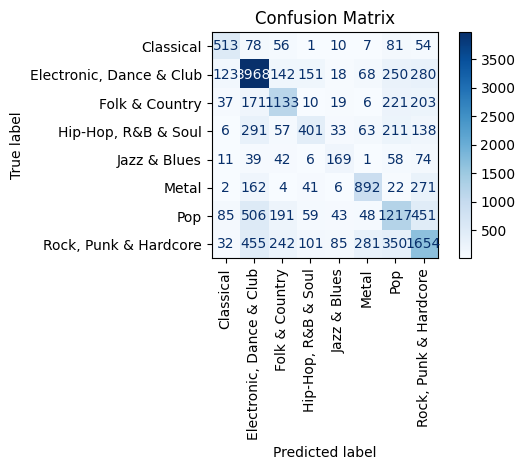

In [187]:
evaluate_model(randomForest, X_test, y_test, True)

La random forest è il modello piu solido del confronto base: guadagna parecchio rispetto alla logistic regression perché gestisce meglio relazioni non lineari e interazioni tra feature. Rimane comunque piu fragile sulle classi meno rappresentate, ma è chiaramente il candidato migliore qui.


Classification Report:
                          precision    recall  f1-score   support

               Classical       0.51      0.73      0.60       800
Electronic, Dance & Club       0.80      0.61      0.69      5000
          Folk & Country       0.45      0.60      0.51      1800
     Hip-Hop, R&B & Soul       0.31      0.49      0.38      1200
            Jazz & Blues       0.24      0.49      0.32       400
                   Metal       0.53      0.78      0.63      1400
                     Pop       0.47      0.35      0.40      2600
   Rock, Punk & Hardcore       0.50      0.36      0.42      3200

                accuracy                           0.53     16400
               macro avg       0.47      0.55      0.49     16400
            weighted avg       0.56      0.53      0.53     16400

Accuracy: 0.5268
Precision: 0.5624
Recall: 0.5268
F1 Score: 0.5303
Top-2 Accuracy: 0.7299


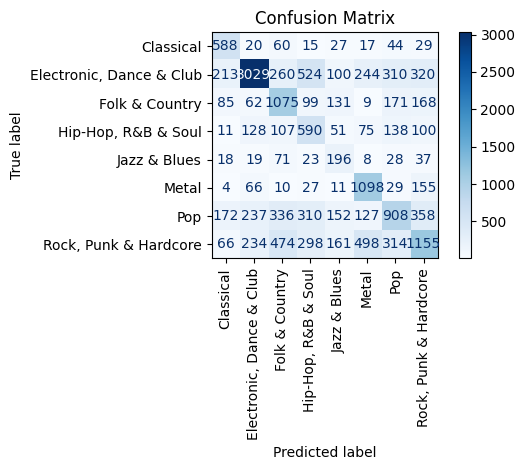

In [188]:
evaluate_model(lgb, X_test, y_test, True)

LightGBM è competitivo, ma in questo setup non supera la random forest. Il risultato suggerisce che il problema è già catturato bene da alberi ensemble e che ulteriori guadagni probabilmente richiedono tuning più fine o feature engineering migliore.


## Analisi dell'Importanza delle Feature
Esaminiamo quali feature sono più rilevanti per la predizione del genere musicale, confrontando i diversi modelli.

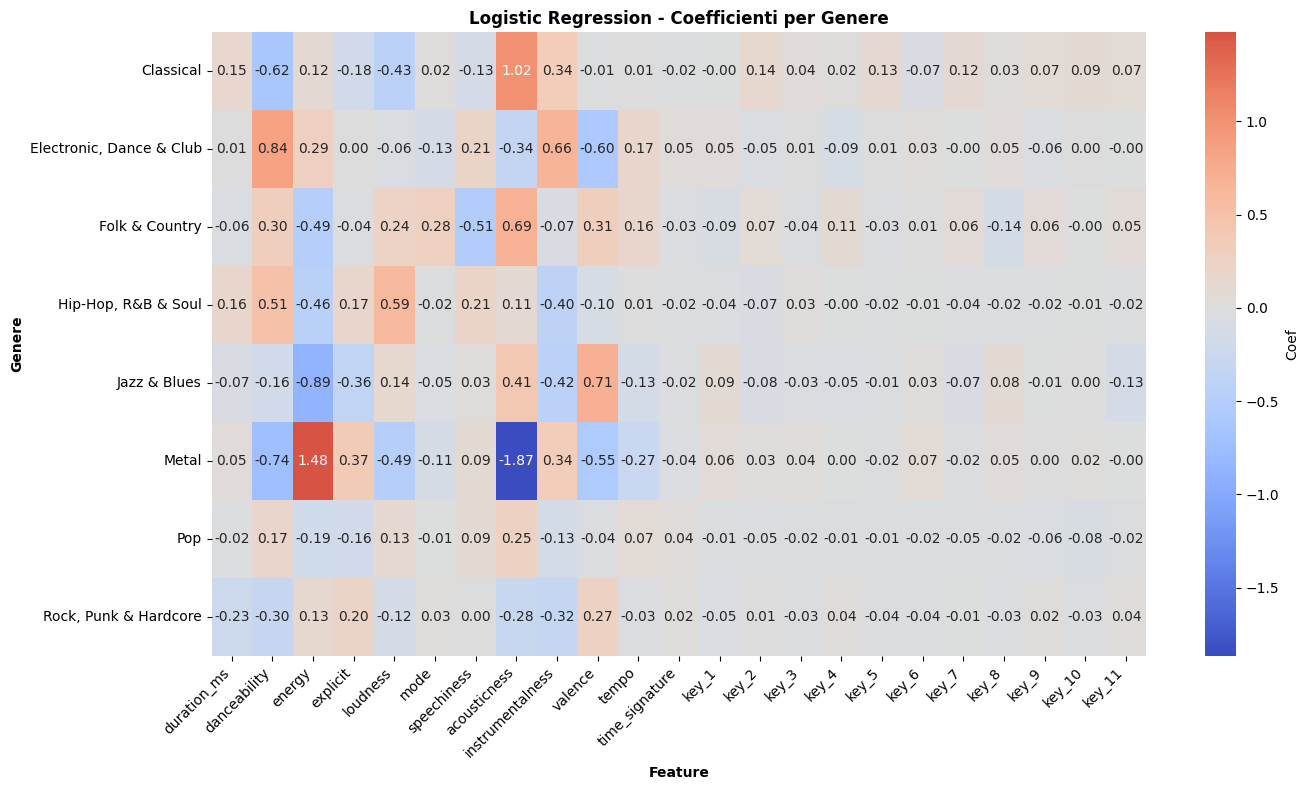

In [204]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

lr_model = logisticRegression.named_steps['classifier']

# Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(pd.DataFrame(lr_model.coef_, columns=X_train.columns, index=lr_model.classes_),
            annot=True, cmap='coolwarm', fmt='.2f', center=0, cbar_kws={'label': 'Coef'})
plt.title('Logistic Regression - Coefficienti per Genere', fontweight='bold')
plt.xlabel('Feature', fontweight='bold')
plt.ylabel('Genere', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

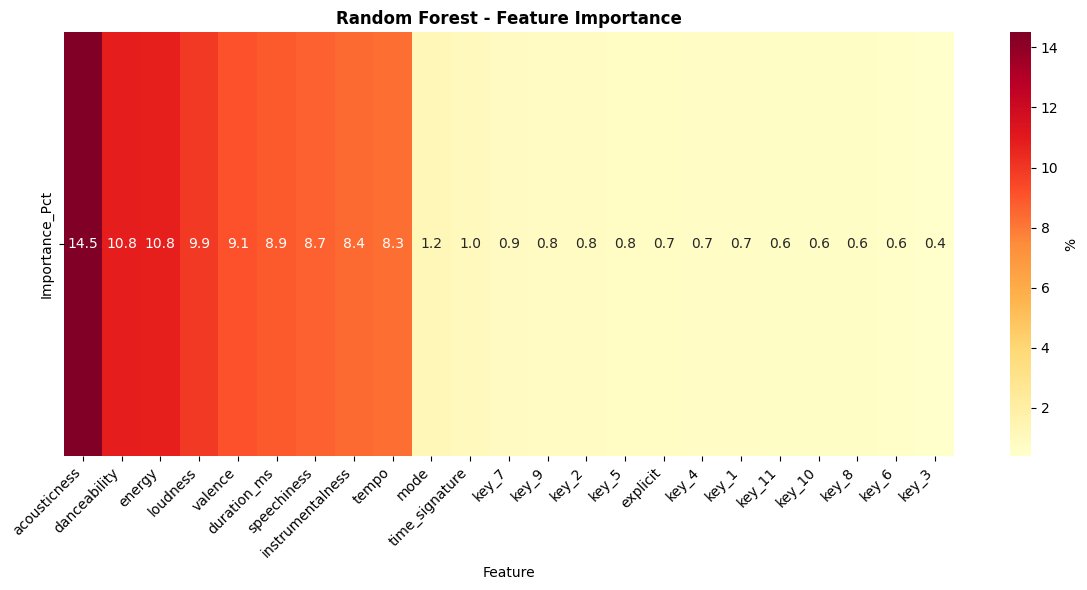

In [190]:
rf_model = randomForest.named_steps['classifier']

# Feature importance
fi = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_,
    'Importance_Pct': rf_model.feature_importances_ * 100
}).sort_values('Importance', ascending=False)

# Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(fi.set_index('Feature')[['Importance_Pct']].T, 
            annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': '%'})
plt.title('Random Forest - Feature Importance', fontweight='bold')
plt.ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

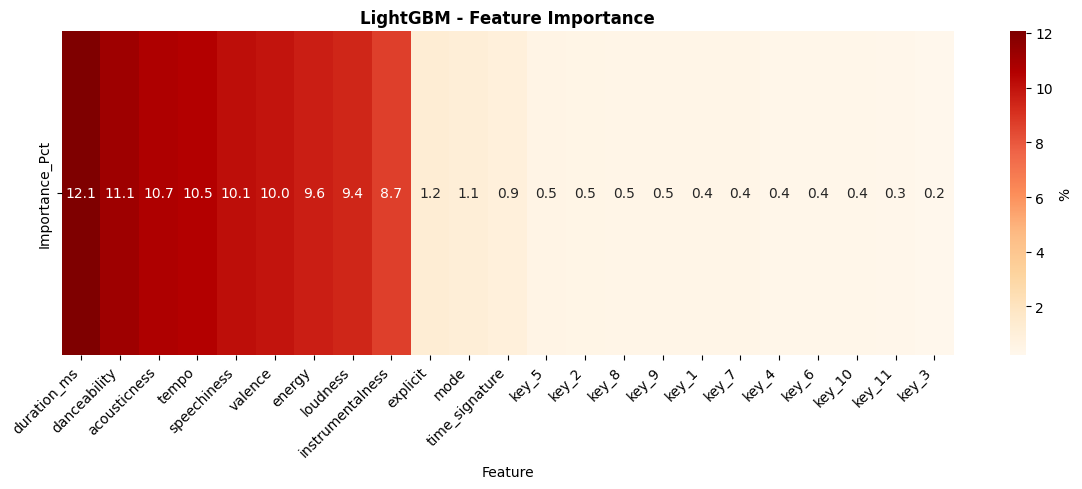

In [191]:
lgb_model = lgb.named_steps['classifier']
fi_lgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgb_model.feature_importances_,
    'Importance_Pct': (lgb_model.feature_importances_ / lgb_model.feature_importances_.sum()) * 100
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 5))
sns.heatmap(fi_lgb.set_index('Feature')[['Importance_Pct']].T, annot=True, fmt='.1f', cmap='OrRd', cbar_kws={'label': '%'})
plt.title('LightGBM - Feature Importance', fontweight='bold')
plt.ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Le feature più informative sono quelle legate a timbro e dinamica del brano: acousticness, danceability, valence, energy, loudness. 

In [192]:
# Analisi coefficienti Logistic Regression
lr_model = logisticRegression.named_steps['classifier']

# Per classificazione multiclasse, visualizza i coefficienti della prima classe
coeff_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print('Top feature - Logistic Regression (coefficienti):')
print(coeff_df.head(10))

Top feature - Logistic Regression (coefficienti):
             Feature  Coefficient
7       acousticness     1.017470
1       danceability    -0.623310
4           loudness    -0.430095
8   instrumentalness     0.337624
3           explicit    -0.177184
0        duration_ms     0.152942
13             key_2     0.135795
6        speechiness    -0.126995
16             key_5     0.126468
18             key_7     0.118194


In [193]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

param_dist_lr = {
    'classifier__C': uniform(0.1, 10),
    'classifier__max_iter': randint(100, 1000),
    'classifier__solver': ['lbfgs', 'saga']
}

param_dist_rf = {
    'classifier__n_estimators': randint(50, 200),
    'classifier__max_depth': [None, 5, 10, 20],
    'classifier__min_samples_split': randint(2, 10)
}

param_dist_lgb = {
    'classifier__n_estimators': randint(50, 200),
    'classifier__max_depth': [5, 10, 20, 30],
    'classifier__learning_rate': uniform(0.01, 0.2),
    'classifier__num_leaves': randint(20, 100),
    'classifier__min_child_samples': randint(5, 30)
}


## Nested Cross Validation
La faccio prima della search finale per misurare la robustezza dell'approccio senza usare il test set. Il tuning interno sceglie i parametri, il loop esterno stima quanto quel tuning generalizza davvero.


In [194]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, RandomizedSearchCV

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model, params in [
    ("Logistic Regression", logisticRegression, param_dist_lr),
    ("Random Forest",       randomForest,       param_dist_rf),
    ("LightGBM",            lgb,                param_dist_lgb) 
]:
    inner_search = RandomizedSearchCV(
        model, params,
        n_iter=5, cv=3, random_state=42, n_jobs=1  # <- togli parallelismo interno
    )
    scores = cross_val_score(inner_search, X_train, y_train, cv=outer_cv, n_jobs=-1)
    print(f"{name}:")
    print(f"  Fold scores: {[f'{s:.4f}' for s in scores]}")
    print(f"  Media: {scores.mean():.4f} (+/- {scores.std():.4f})\n")

Logistic Regression:
  Fold scores: ['0.3986', '0.3921', '0.3999', '0.4033', '0.3992']
  Media: 0.3986 (+/- 0.0037)

Random Forest:
  Fold scores: ['0.5997', '0.5985', '0.6048', '0.5987', '0.6065']
  Media: 0.6016 (+/- 0.0033)

LightGBM:
  Fold scores: ['0.5730', '0.5717', '0.5771', '0.5757', '0.5764']
  Media: 0.5748 (+/- 0.0021)



Random Forest è il modello migliore nella nested CV, seguito da LightGBM. 
Entrambi i modelli sono consistenti tra i fold (std < 0.01), a conferma che 
i risultati non dipendono dalla particolare suddivisione dei dati. La logistica 
si ferma circa 20 punti percentuali sotto Random Forest.

Il risultato è giustificato: le feature audio non separano linearmente i generi. 
Generi come Rock e Metal, o Electronic e Pop, condividono range simili di energia 
e danceability — la differenza sta nelle combinazioni, non nei valori singoli. 
Random Forest e LightGBM catturano queste interazioni tramite gli split degli 
alberi, la regressione logistica no.

## Ricerca finale degli Iperparametri
Dopo aver visto che l'approccio regge alla nested CV, faccio una RandomizedSearchCV finale sul training set per ottenere il modello da confrontare e consegnare.


In [195]:
param_dist_lr_final = {
    'classifier__C': uniform(0.1, 10),
    'classifier__max_iter': randint(100, 1000),
    'classifier__solver': ['lbfgs', 'saga']
}

random_search_lr = RandomizedSearchCV(
    logisticRegression,
    param_dist_lr_final,
    n_iter=15,
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_lr.fit(X_train, y_train)
print(f'Miglior parametri LR: {random_search_lr.best_params_}')
print(f'Miglior score CV: {random_search_lr.best_score_:.4f}')


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Miglior parametri LR: {'classifier__C': np.float64(0.6808361216819946), 'classifier__max_iter': 187, 'classifier__solver': 'lbfgs'}
Miglior score CV: 0.3988


In [196]:
y_pred_lr_opt = random_search_lr.predict(X_test)
lr_opt_score = accuracy_score(y_test, y_pred_lr_opt)
print(f'LR ottimizzato:')
evaluate_model(random_search_lr, X_test, y_test, False)

LR ottimizzato:
Classification Report:
                          precision    recall  f1-score   support

               Classical       0.43      0.70      0.53       800
Electronic, Dance & Club       0.75      0.47      0.58      5000
          Folk & Country       0.35      0.39      0.37      1800
     Hip-Hop, R&B & Soul       0.17      0.32      0.22      1200
            Jazz & Blues       0.11      0.43      0.18       400
                   Metal       0.42      0.78      0.55      1400
                     Pop       0.24      0.06      0.09      2600
   Rock, Punk & Hardcore       0.37      0.34      0.35      3200

                accuracy                           0.40     16400
               macro avg       0.35      0.44      0.36     16400
            weighted avg       0.45      0.40      0.39     16400

Accuracy: 0.3968
Precision: 0.4485
Recall: 0.3968
F1 Score: 0.3939
Top-2 Accuracy: 0.5916


In [197]:
param_dist_rf_final = {
    'classifier__n_estimators': randint(50, 200),
    'classifier__max_depth': [None, 5, 10, 20],
    'classifier__min_samples_split': randint(2, 10)
}

random_search_rf = RandomizedSearchCV(
    randomForest,
    param_dist_rf_final,
    n_iter=15,
    cv=5,
    random_state=42,
    n_jobs=1,
    verbose=1
)

random_search_rf.fit(X_train, y_train)
print(f'Miglior parametri RF: {random_search_rf.best_params_}')
print(f'Miglior score CV: {random_search_rf.best_score_:.4f}')

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Miglior parametri RF: {'classifier__max_depth': None, 'classifier__min_samples_split': 6, 'classifier__n_estimators': 152}
Miglior score CV: 0.5996


In [198]:
y_pred_rf_opt = random_search_rf.predict(X_test)
rf_opt_score = accuracy_score(y_test, y_pred_rf_opt)
print(f'RF ottimizzato:')
evaluate_model(random_search_rf, X_test, y_test, False)

RF ottimizzato:
Classification Report:
                          precision    recall  f1-score   support

               Classical       0.60      0.70      0.65       800
Electronic, Dance & Club       0.75      0.76      0.75      5000
          Folk & Country       0.58      0.67      0.62      1800
     Hip-Hop, R&B & Soul       0.50      0.39      0.44      1200
            Jazz & Blues       0.44      0.43      0.44       400
                   Metal       0.63      0.67      0.65      1400
                     Pop       0.50      0.48      0.49      2600
   Rock, Punk & Hardcore       0.54      0.51      0.52      3200

                accuracy                           0.61     16400
               macro avg       0.57      0.58      0.57     16400
            weighted avg       0.61      0.61      0.61     16400

Accuracy: 0.6101
Precision: 0.6063
Recall: 0.6101
F1 Score: 0.6070
Top-2 Accuracy: 0.8019


In [199]:
param_dist_lgb_final = {
    'classifier__n_estimators': randint(50, 200),
    'classifier__max_depth': [5, 10, 20, 30],
    'classifier__learning_rate': uniform(0.01, 0.2),
    'classifier__num_leaves': randint(20, 100),
    'classifier__min_child_samples': randint(5, 30)
}

random_search_lgb = RandomizedSearchCV(
    lgb,
    param_dist_lgb_final,
    n_iter=15,
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_lgb.fit(X_train, y_train)
print(f'Miglior parametri LGB: {random_search_lgb.best_params_}')
print(f'Miglior score CV: {random_search_lgb.best_score_:.4f}')

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Miglior parametri LGB: {'classifier__learning_rate': np.float64(0.12973169683940733), 'classifier__max_depth': 20, 'classifier__min_child_samples': 23, 'classifier__n_estimators': 124, 'classifier__num_leaves': 94}
Miglior score CV: 0.5790


In [200]:
y_pred_lgb_opt = random_search_lgb.predict(X_test)
lgb_opt_score = accuracy_score(y_test, y_pred_lgb_opt)
print(f'LGB ottimizzato:')
evaluate_model(random_search_lgb, X_test, y_test, False)

LGB ottimizzato:
Classification Report:
                          precision    recall  f1-score   support

               Classical       0.59      0.70      0.64       800
Electronic, Dance & Club       0.80      0.68      0.73      5000
          Folk & Country       0.52      0.66      0.58      1800
     Hip-Hop, R&B & Soul       0.38      0.46      0.41      1200
            Jazz & Blues       0.39      0.46      0.42       400
                   Metal       0.59      0.73      0.65      1400
                     Pop       0.48      0.45      0.47      2600
   Rock, Punk & Hardcore       0.52      0.45      0.49      3200

                accuracy                           0.58     16400
               macro avg       0.53      0.57      0.55     16400
            weighted avg       0.59      0.58      0.58     16400

Accuracy: 0.5810
Precision: 0.5941
Recall: 0.5810
F1 Score: 0.5834
Top-2 Accuracy: 0.7823


La ricerca degli iperparametri cambia poco i risultati: la logistic regression resta invariata, mentre random forest e LightGBM migliorano solo marginalmente. Questo vuol dire che i modelli base erano già abbastanza vicini al loro plateau sul dataset.


I tre modelli confermano un tetto di performance intorno al 60% per il task di classificazione del genere musicale. Questo non è necessariamente un limite del modello, ma probabilmente del problema stesso: i macrogeneri sono categorie culturali, non acustiche, e tracce stilisticamente ibride (es. indie-pop, electro-funk) sono genuinamente ambigue anche per un ascoltatore umano. Le feature audio catturano il suono, non il contesto storico o culturale che definisce un genere.

## Intervallo di Confidenza e Confronto Statistico dei Modelli

Le accuracy sul test set sono stime: con ~16.000 istanze possiamo calcolare intervalli di confidenza al 95% usando il metodo di Wilson (equivalente alla formula di Bernoulli vista a lezione) e verificare se la differenza tra i modelli migliori è statisticamente significativa.

In [ ]:
from statsmodels.stats.proportion import proportion_confint, proportions_ztest

n = len(y_test)
print(f"Dimensione del test set: {n} tracce")

print("Intervalli di confidenza al 95%:")
for name, acc in [("Logistic Regression", lr_opt_score),
                  ("Random Forest",      rf_opt_score),
                  ("LightGBM",           lgb_opt_score)]:
    lo, hi = proportion_confint(int(acc * n), n, alpha=0.05, method='wilson')
    print(f"{name:<22} accuracy={acc:.4f}  IC 95% [{lo:.4f}, {hi:.4f}]")

print("Confronto Random Forest vs LightGBM (z-test sulle proporzioni):")
counts = [rf_opt_score * n, lgb_opt_score * n]
stat, pvalue = proportions_ztest(counts, [n, n])
esito = "significativa" if pvalue < 0.05 else "NON significativa"
print(f"z={stat:.3f}, p-value={pvalue:.4f} -> differenza {esito} al 95%")


Dimensione del test set: 16400 tracce
Intervalli di confidenza al 95%:
Logistic Regression    accuracy=0.3968  IC 95% [0.3893, 0.4043]
Random Forest          accuracy=0.6101  IC 95% [0.6026, 0.6175]
LightGBM               accuracy=0.5810  IC 95% [0.5735, 0.5886]
Confronto Random Forest vs LightGBM (z-test sulle proporzioni):
z=5.355, p-value=0.0000 -> differenza significativa al 95%


Gli intervalli di confidenza al 95% confermano che le stime di accuracy sono affidabili:
con 16k istanze di test gli intervalli sono molto stretti, il che significa
che rieseguendo l'esperimento su nuovi dati simili ci aspettiamo risultati dentro questo range.

Gli intervalli di RF [0.60, 0.62] e LightGBM [0.57, 0.59] non si sovrappongono,
il che suggerisce già visivamente che la differenza è reale. Il z-test sulle proporzioni
lo conferma formalmente: z=5.355, p-value≈0 — la differenza tra i due modelli è
statisticamente significativa al 95% di confidenza e non è frutto della casualità
dello split train/test.